# Setup

In [1]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
import random

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [2]:
def calc_wape(total_error_abs, total_sales):
    return round(total_error_abs / total_sales, 4) if total_sales != 0 else np.nan

def calc_bias(total_error, total_sales):
    return round(total_error / total_sales, 4) if total_sales != 0 else np.nan

def calc_mae(error_abs):
    if len(error_abs) == 0:
        return np.nan
    return round(np.mean(error_abs), 4)

def calc_rmse(error):
    if len(error) == 0:
        return np.nan
    return round(np.sqrt(np.mean(np.square(error))), 4)

# Load data

In [3]:
data_all = pd.read_parquet('../sandbox/data_genex_venta_transfer.parquet')

In [4]:
demand_summary = pd.read_parquet('../sandbox/demand_summary.parquet')

# Forecast Tricot

In [5]:
data_all['forecast_tricot'] = (
    (data_all['vta_promedio'] * data_all['factor'] * data_all['semana_vta'] + 0.6)
    .fillna(0)
    .astype(int)
    .astype('UInt16')
)


data_all['error'] = data_all['forecast_tricot'] - data_all['real_sales']
data_all['error_abs'] = data_all['error'].abs()

data_all['wape_ind'] = (data_all['error_abs'] / data_all['real_sales']).fillna(0).round(4)
data_all['bias_ind'] = (data_all['error'] / data_all['real_sales']).fillna(0).round(4)

# Explorar error actual

In [6]:
cond1 = data_all["can_final"] > 0 # Que saliera repo
#cond1 = data_all["can_original"] > 0 # Que generara repo
cond2 = data_all["repo_x_dda"] > 0 # Que hubiera repo x dda calculada
cond3 = data_all["repo_x_dda"] >= data_all["repo_x_ume"] # Que la repo sea por demanda

data_repo_x_dda = data_all.loc[cond1 & cond2 & cond3].copy()

In [7]:
tricot_df = data_repo_x_dda.copy()

tricot_df = tricot_df[['id','cod_sucursal','nombre_sucursal','cod_producto','nombre_depto','nombre_linea','cod_talla','nom_talla','week_number','week_start',
                             'vta_promedio','factor','semana_vta',
                             'repo_x_dda','repo_x_ume','can_final',
                             'real_sales','forecast_tricot', 'error','error_abs','bias_ind']]

## a) Error total

In [8]:
len(data_repo_x_dda)

354456

In [9]:
sum(data_repo_x_dda['can_final'])

1990104.0

In [10]:
wape = calc_wape(tricot_df['error_abs'].sum(), tricot_df['real_sales'].sum())
bias = calc_bias(tricot_df['error'].sum(), tricot_df['real_sales'].sum())
mae = calc_mae(tricot_df['error_abs'])
rmse = calc_rmse(tricot_df['error'])

In [11]:
print(f"WAPE: {wape:.0%}")
print(f"BIAS: {bias:.0%}")
print(f"MAE: {mae:.0f}")
print(f"RMSE: {rmse:.0f}")

WAPE: 170%
BIAS: 156%
MAE: 11
RMSE: 46


In [12]:
tricot_df['bias_cat'] = pd.cut(
    tricot_df['bias_ind'],
    bins=[-np.inf, -0.15, 0.15, 1.0, 2.0, 3.0, np.inf],
    labels=['-100% a -15%', '-15% a 15%', '15% a 100%', '100% a 200%', '200% a 300%', '> 300%'],
    right=False,
    ordered=True
)

tricot_df.groupby('bias_cat').agg(
    count=('bias_cat', 'size'),
    mean_bias=('bias_ind', 'mean')
)

,count,mean_bias
bias_cat,,
-100% a -15%,29230,-0.339764
-15% a 15%,45540,0.005466
15% a 100%,77984,0.48243
100% a 200%,60019,1.298071
200% a 300%,32344,2.241597
> 300%,76726,8.215315


In [13]:
bias_cat_bias_ind = tricot_df.pivot_table(index='week_number', columns='bias_cat', values='bias_ind', aggfunc='mean')
bias_cat_can_final = tricot_df.pivot_table(index='week_number', columns='bias_cat', values='can_final', aggfunc='sum')
bias_cat_can_final = (bias_cat_can_final/ bias_cat_can_final.values.sum()).round(3)

## b) Error por semana

In [14]:
tricot_df_weekly = tricot_df.groupby(['week_start']).apply(
    lambda g: pd.Series({
        'can_final': g['can_final'].sum(),
        'wape': calc_wape(g['error_abs'].sum(), g['real_sales'].sum()),
        'bias': calc_bias(g['error'].sum(), g['real_sales'].sum()),
        'mae': calc_mae(g['error_abs']),
        'rmse': calc_rmse(g['error']),
        'vta_promedio': g['vta_promedio'].mean(),
        'factor': g['factor'].mean(),
        'semana_vta': g['semana_vta'].mean(),
    })
).reset_index()

tricot_df_weekly['prop_can_final'] = (tricot_df_weekly['can_final'] / tricot_df_weekly['can_final'].sum()).round(4)

tricot_df_weekly = tricot_df_weekly.query('prop_can_final >= 0.005').reset_index(drop=True)

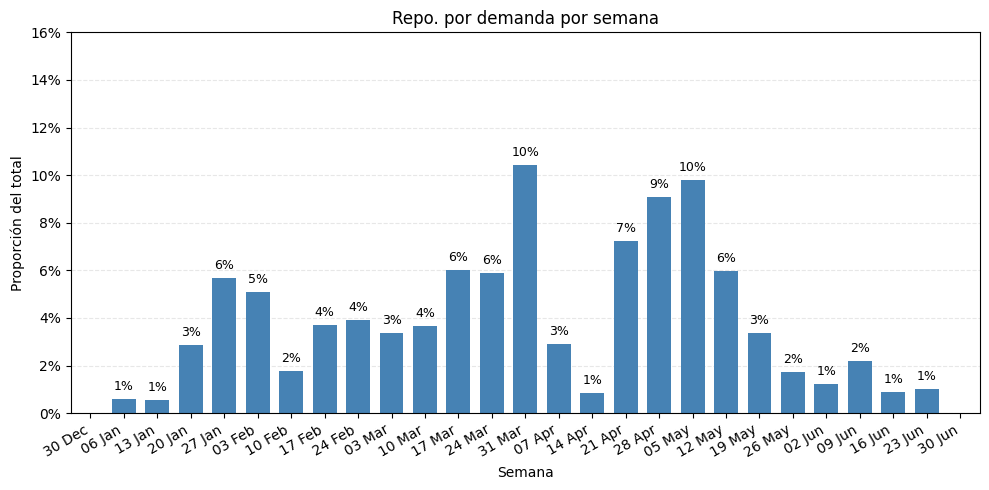

In [15]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 5))

bars = plt.bar(
    tricot_df_weekly['week_start'],
    tricot_df_weekly['prop_can_final'],
    width=5,
    align='center',
    color='steelblue',
    zorder=2
)

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30, ha='right')

plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.02))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 0.16)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.0025,
        f"{height:.0%}",
        ha='center', va='bottom', fontsize=9
    )

plt.ylabel("Proporción del total")
plt.xlabel("Semana")

plt.title("Repo. por demanda por semana")
plt.tight_layout()
plt.grid(axis="y", linestyle='--', alpha=0.3)
plt.show()

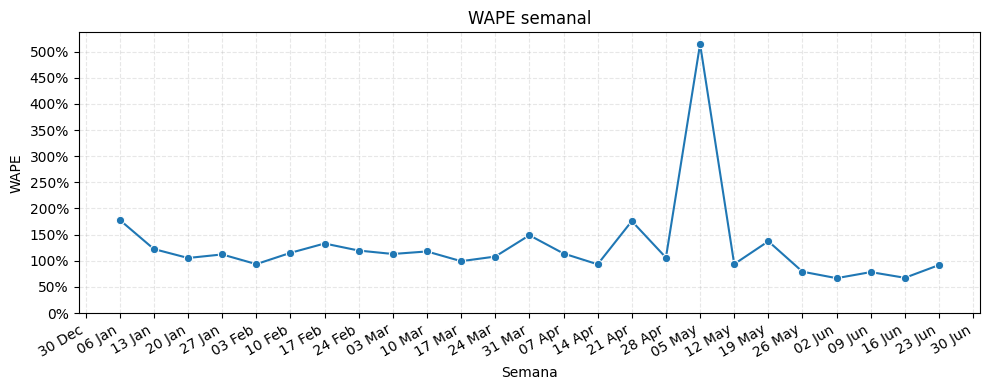

In [16]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='wape', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30, ha='right')
plt.xlabel('Semana')

plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.ylabel('WAPE')


plt.title("WAPE semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

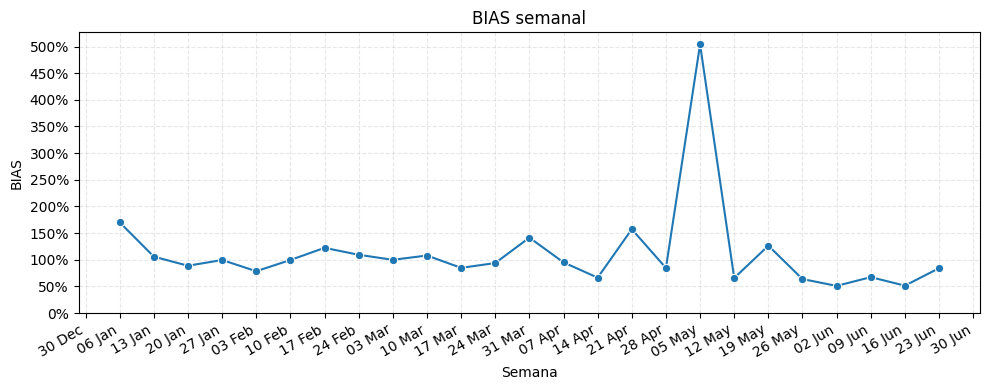

In [17]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='bias', data=tricot_df_weekly,
             marker = 'o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30, ha='right')
plt.xlabel('Semana')

plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.ylabel('BIAS')


plt.title("BIAS semanal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

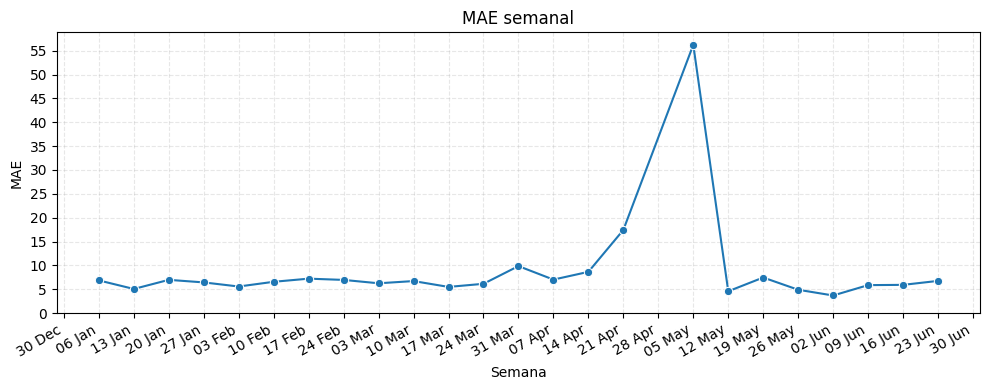

In [18]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='mae', data=tricot_df_weekly.drop(index=16),
             marker='o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(5))
plt.ylim(bottom=0)
plt.xticks(rotation=30, ha='right')
plt.ylabel('MAE')
plt.xlabel('Semana')

plt.title("MAE semanal")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

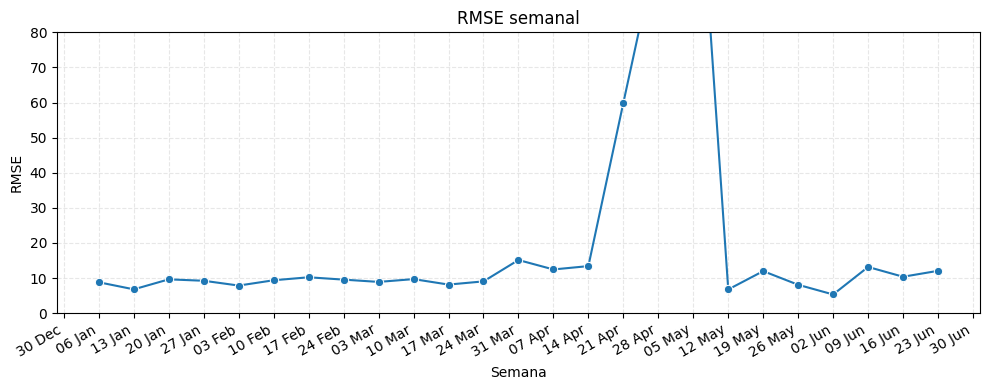

In [19]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='rmse', data=tricot_df_weekly.drop(index=16),
             marker='o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(10))
plt.ylim(bottom=0, top=80)
plt.xticks(rotation=30, ha='right')
plt.ylabel('RMSE')
plt.xlabel('Semana')

plt.title("RMSE semanal")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

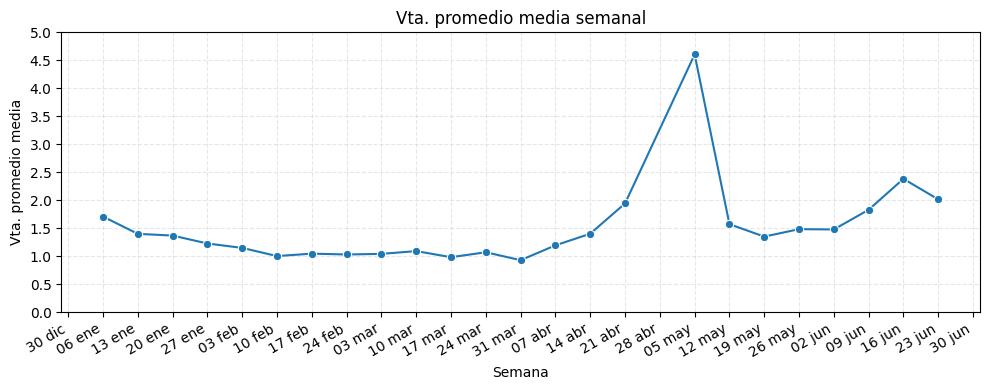

In [53]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='vta_promedio', data=tricot_df_weekly.drop(index=16),
             marker='o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.ylim(0, 5)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Vta. promedio media')
plt.xlabel('Semana')

plt.title("Vta. promedio media semanal")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

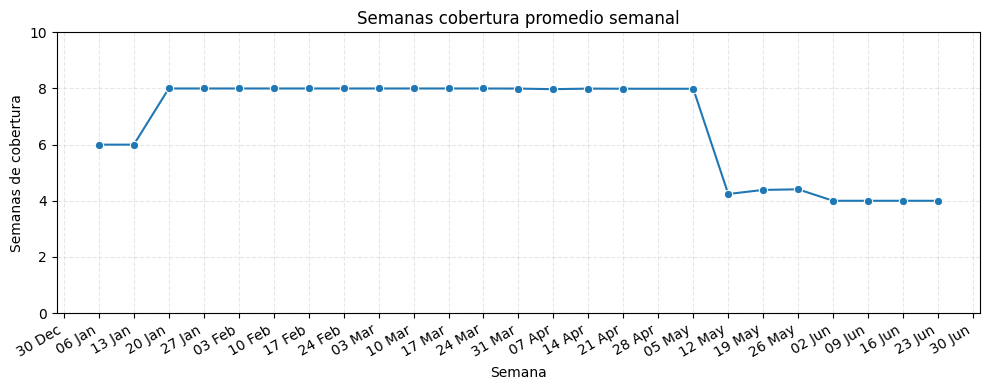

In [21]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='semana_vta', data=tricot_df_weekly.drop(index=16),
             marker='o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(2))
plt.ylim(0, 10)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Semanas de cobertura')
plt.xlabel('Semana')

plt.title("Semanas cobertura promedio semanal")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

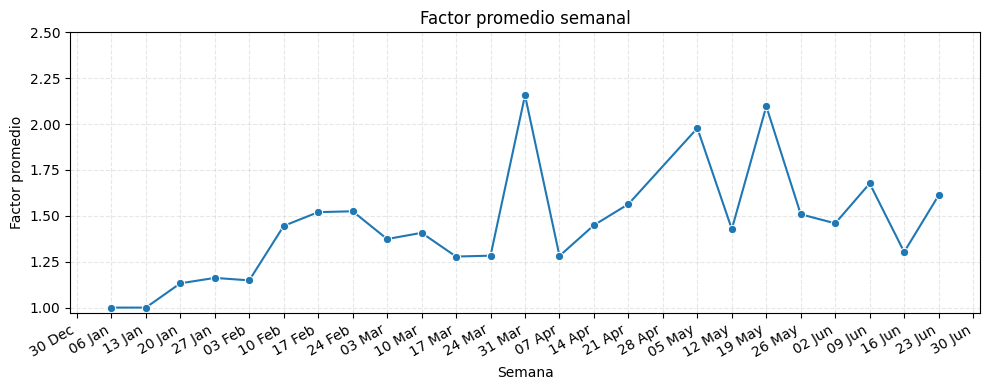

In [22]:
plt.figure(figsize=(10, 4))

sns.lineplot(x='week_start', y='factor', data=tricot_df_weekly.drop(index=16),
             marker='o')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.ylim(0.97, 2.5)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Factor promedio')
plt.xlabel('Semana')

plt.title("Factor promedio semanal")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## c) Error por semana en sucursal

In [23]:
tricot_df_week_number = tricot_df.groupby('week_number', ).apply(
    lambda g: pd.Series({
        'can_final': g['can_final'].sum(),
        'wape': calc_wape(g['error_abs'].sum(), g['real_sales'].sum()),
        'bias': calc_bias(g['error'].sum(), g['real_sales'].sum()),
        'mae': calc_mae(g['error_abs']),
        'rmse': calc_rmse(g['error']),
        'vta_promedio': g['vta_promedio'].mean(),
        'factor': g['factor'].mean(),
        'semana_vta': g['semana_vta'].mean(),
        'forecast_tricot': g['forecast_tricot'].mean(),
        'real_sales': g['real_sales'].mean()
    })
).reset_index()

tricot_df_week_number['prop_can_final'] = (tricot_df_week_number['can_final'] / tricot_df_week_number['can_final'].sum()).round(4)

tricot_df_week_number = tricot_df_week_number.query('prop_can_final >= 0.01').reset_index(drop=True)

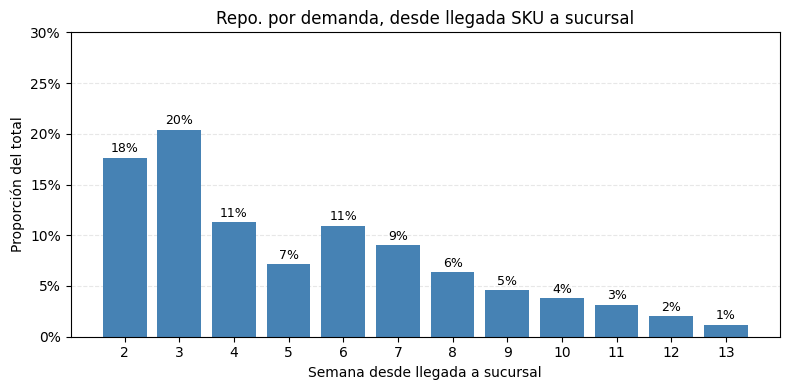

In [54]:
plt.figure(figsize=(8, 4))

bars = plt.bar(
    tricot_df_week_number['week_number'],
    tricot_df_week_number['prop_can_final'],
    align='center',
    color='steelblue',
    zorder=2
)

# Eje X con saltos de 1
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

# Eje Y en porcentajes (0% a 30%)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.05))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 0.3)

# Etiquetas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # centro de la barra
        height + 0.0025,                   # un poco arriba del tope
        f"{height:.0%}",                  # formato en %
        ha='center', va='bottom', fontsize=9
    )

plt.ylabel("Proporción del total")
plt.xlabel("Semana desde llegada a sucursal")

plt.title("Repo. por demanda, desde llegada SKU a sucursal")
plt.tight_layout()
plt.grid(axis="y", linestyle='--', alpha=0.3)
plt.show()

In [60]:
demand_summary_all = demand_summary.groupby('weeks_until_first_sale').agg(
    predist_total = ('PREDISTRIBUIDA', 'sum'),
    repo_auto_total = ('REPOSICION AUTOMATIC', 'sum'),
    predist_mean = ('PREDISTRIBUIDA', 'mean'),
    repo_auto_mean = ('REPOSICION AUTOMATIC', 'mean'),
).round(1).reset_index()#.to_excel("../sandbox/weeks_until_first_sale_all.xlsx", index=False)


demand_summary_all['repo_auto_total_pct'] = demand_summary_all['repo_auto_total'] / demand_summary_all['repo_auto_total'].sum()
demand_summary_all['predist_total_pct'] = demand_summary_all['predist_total'] / demand_summary_all['predist_total'].sum()

demand_summary_all['repo_auto_total_pct_cum'] = demand_summary_all['repo_auto_total_pct'].cumsum()

demand_summary_all = demand_summary_all.query('repo_auto_total_pct_cum <= 0.985')

(demand_summary_all.query('weeks_until_first_sale <= 1')['repo_auto_total_pct'].sum() * 100).round(0)

np.float64(56.0)

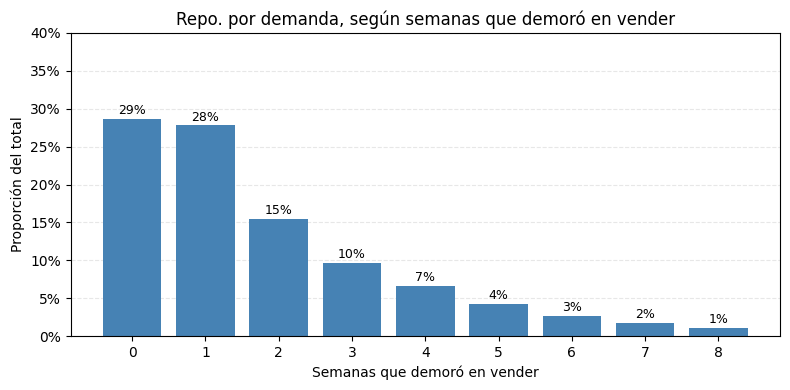

In [61]:
plt.figure(figsize=(8, 4))

bars = plt.bar(
    demand_summary_all['weeks_until_first_sale'],
    demand_summary_all['repo_auto_total_pct'],
    align='center',
    color='steelblue',
    zorder=2
)

# Eje X con saltos de 1
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

# Eje Y en porcentajes (0% a 30%)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.05))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 0.4)

# Etiquetas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # centro de la barra
        height + 0.0025,                   # un poco arriba del tope
        f"{height:.0%}",                  # formato en %
        ha='center', va='bottom', fontsize=9
    )

plt.ylabel("Proporción del total")
plt.xlabel("Semanas que demoró en vender")

plt.title("Repo. por demanda, según semanas que demoró en vender")
plt.tight_layout()
plt.grid(axis="y", linestyle='--', alpha=0.3)
plt.show()

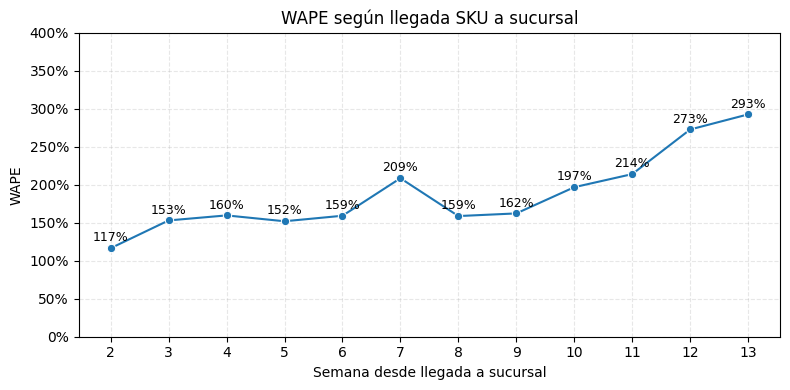

In [25]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='wape', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 4)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("WAPE")

for x, y in zip(tricot_df_week_number['week_number'], tricot_df_week_number['wape']):
    plt.text(x, y + 0.05, f"{y:.0%}", ha='center', va='bottom', fontsize=9)

plt.title("WAPE según llegada SKU a sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

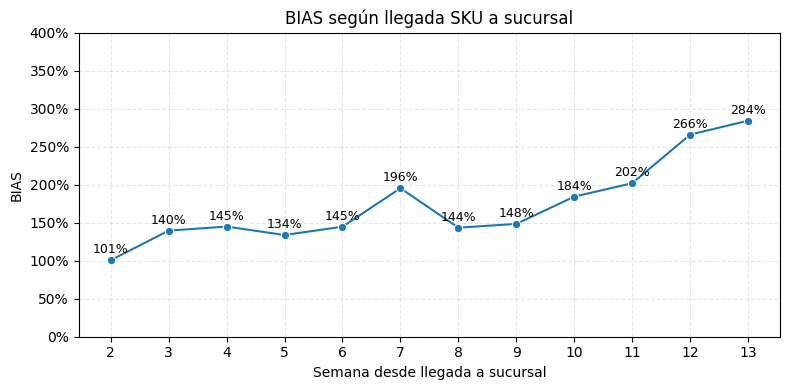

In [55]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='bias', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, 4)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("BIAS")

for x, y in zip(tricot_df_week_number['week_number'], tricot_df_week_number['bias']):
    plt.text(x, y + 0.05, f"{y:.0%}", ha='center', va='bottom', fontsize=9)

plt.title("BIAS según llegada SKU a sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

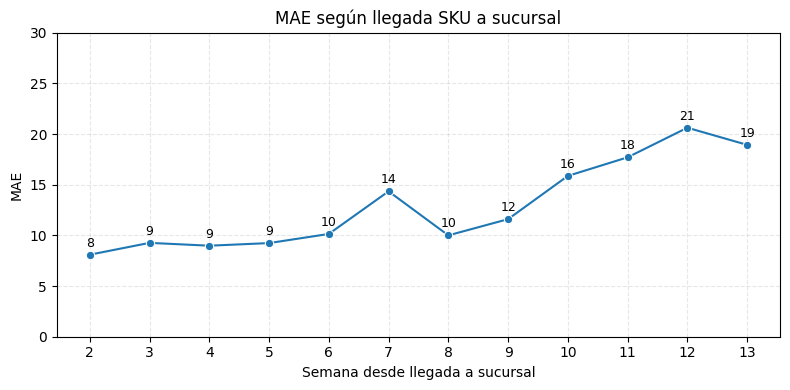

In [56]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='mae', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(5))
plt.ylim(0, 30)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("MAE")

for x, y in zip(tricot_df_week_number['week_number'], tricot_df_week_number['mae']):
    plt.text(x, y + 0.5, f"{y:.0f}", ha='center', va='bottom', fontsize=9)

plt.title("MAE según llegada SKU a sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

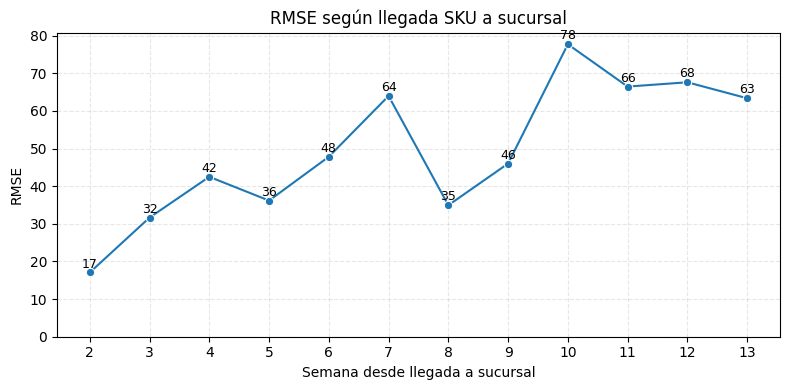

In [63]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='rmse', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(10))
plt.ylim(bottom=0)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("RMSE")

for x, y in zip(tricot_df_week_number['week_number'], tricot_df_week_number['rmse']):
    plt.text(x, y + 0.5, f"{y:.0f}", ha='center', va='bottom', fontsize=9)

plt.title("RMSE según llegada SKU a sucursal")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

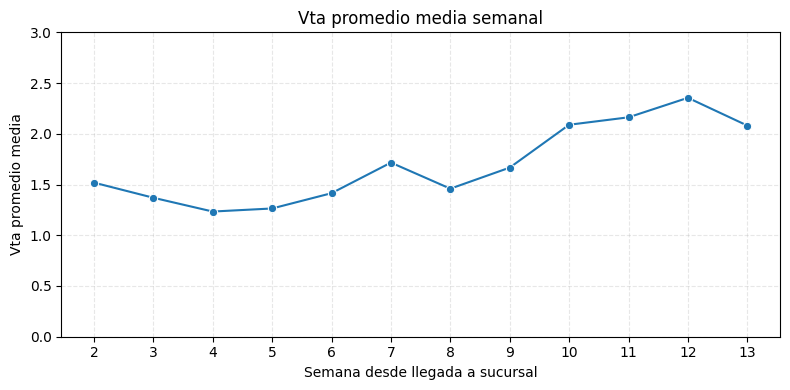

In [58]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='vta_promedio', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.ylim(0, 3)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("Vta promedio media")

plt.title("Vta promedio media semanal")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

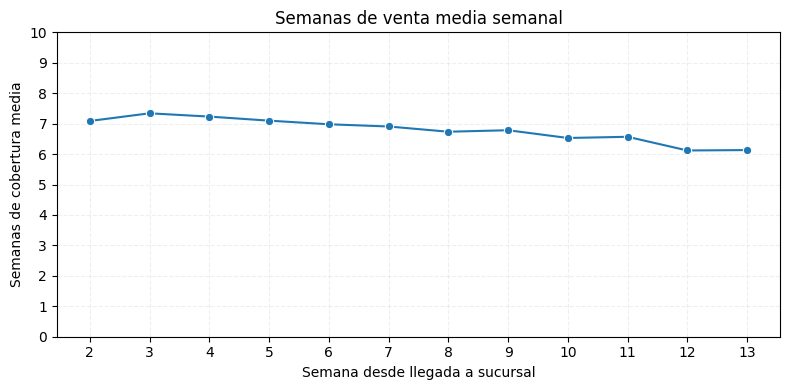

In [64]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='semana_vta', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.ylim(0, 10)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("Semanas de cobertura media")

plt.title("Semanas de venta media semanal")
plt.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

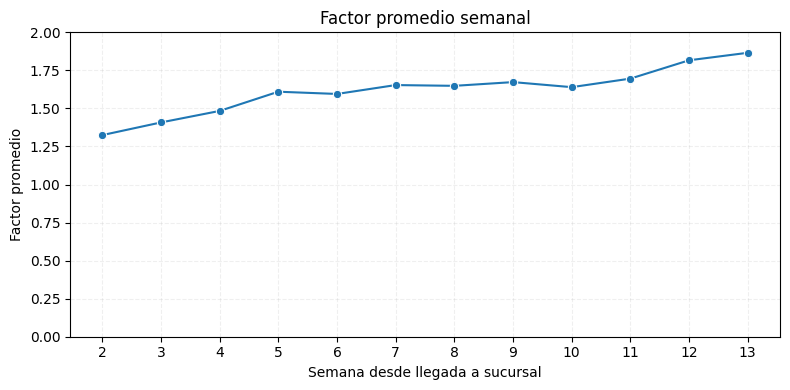

In [31]:
plt.figure(figsize=(8, 4))

sns.lineplot(x='week_number', y='factor', data=tricot_df_week_number,
             marker='o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.ylim(0, 2)
plt.xlabel("Semana desde llegada a sucursal")
plt.ylabel("Factor promedio")

plt.title("Factor promedio semanal")
plt.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

## d) Por depto

In [32]:
tricot_df_depto = tricot_df.groupby(['nombre_depto',], ).apply(
    lambda g: pd.Series({
        'can_final': g['can_final'].sum(),
        'wape': calc_wape(g['error_abs'].sum(), g['real_sales'].sum()),
        'bias': calc_bias(g['error'].sum(), g['real_sales'].sum()),
        'mae': calc_mae(g['error_abs']),
        'vta_promedio': g['vta_promedio'].mean(),
        'factor': g['factor'].mean(),
        'semana_vta': g['semana_vta'].mean(),
        'can_final_mean': g['can_final'].mean()
    })
).reset_index()

tricot_df_depto['prop_can_final'] = (tricot_df_depto['can_final'] / tricot_df_depto['can_final'].sum()).round(4)

tricot_df_depto = tricot_df_depto.query('prop_can_final >= 0.005').reset_index(drop=True)

tricot_df_depto

,nombre_depto,can_final,wape,bias,mae,vta_promedio,factor,semana_vta,can_final_mean,prop_can_final
0,Accesorios,103553.0,1.6320,1.5012,21.7369,2.607997,1.879010,6.727895,8.645988,0.0520
1,Corseteria,67117.0,1.1847,1.0796,9.9975,1.424702,1.676328,7.927336,6.830552,0.0337
2,Deporte hombre,127133.0,1.7405,1.6064,11.1159,1.546438,1.482154,7.276596,5.431641,0.0639
3,Deporte mujer,110142.0,1.1452,1.0134,6.7780,1.155966,1.498344,7.153612,5.594941,0.0553
4,Formal hombres,76931.0,1.3807,1.2427,11.9104,1.721606,1.908827,6.668553,7.022455,0.0387
5,Juvenil hombres,283820.0,1.7407,1.6050,7.7025,1.017308,1.588888,6.827209,4.623078,0.1426
6,Juvenil mujer,509226.0,1.6119,1.5004,8.0888,1.347132,1.457756,6.704079,5.246345,0.2559
7,Lenceria,261957.0,1.8698,1.6685,25.8824,3.478655,1.637239,6.770055,8.017537,0.1316
8,Ninas,75673.0,2.0448,1.9055,12.9445,1.532061,1.589308,6.924126,5.489119,0.0380
9,Ninos,78439.0,1.5442,1.3884,10.0880,1.259266,1.579336,7.370529,5.166919,0.0394


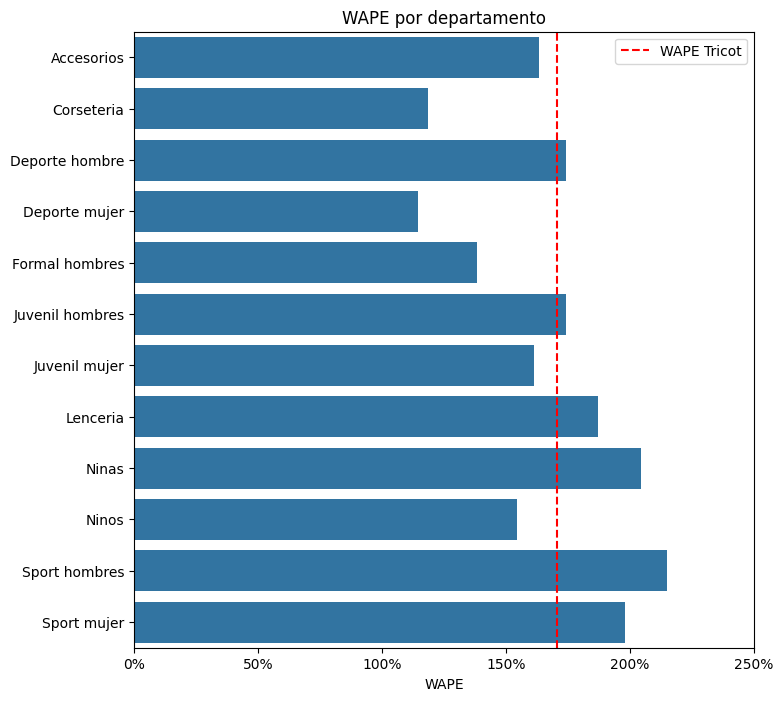

In [33]:
#barplot by depto for the wape

plt.figure(figsize=(8, 8))

sns.barplot(data=tricot_df_depto, x="wape", y="nombre_depto", legend=False)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.xlim(0, 2.5)

#constant line at x = 1
plt.axvline(x=wape, color='red', linestyle='--', label='WAPE Tricot')
plt.legend()
plt.title('WAPE por departamento')
plt.xlabel('WAPE')
plt.ylabel('')

plt.show()

In [34]:
tricot_df.query('week_number >= 6 and week_number <= 10 and can_final >= 10')

,id,cod_sucursal,nombre_sucursal,cod_producto,nombre_depto,nombre_linea,cod_talla,nom_talla,week_number,week_start,...,semana_vta,repo_x_dda,repo_x_ume,can_final,real_sales,forecast_tricot,error,error_abs,bias_ind,bias_cat
11956,1273115103,1,MONJITAS,273115,Deporte hombre,Poleras,103,M,8,2025-03-17,...,8.0,11.0,0.0,10.0,9,24,15,15,1.6667,100% a 200%
15602,1273148105,1,MONJITAS,273148,Deporte hombre,Poleras,105,L,9,2025-04-28,...,4.0,29.0,4.0,26.0,6,18,12,12,2.0,200% a 300%
16224,1273154105,1,MONJITAS,273154,Deporte hombre,Poleras,105,L,7,2025-04-14,...,8.0,8.0,3.0,12.0,19,15,-4,4,-0.2105,-100% a -15%
16480,1273156106,1,MONJITAS,273156,Deporte hombre,Pantalon de buzo,106,XL,8,2025-03-31,...,8.0,11.0,0.0,11.0,13,23,10,10,0.7692,15% a 100%
16806,1273160103,1,MONJITAS,273160,Deporte hombre,Pantalon de buzo,103,M,10,2025-04-28,...,4.0,14.0,0.0,11.0,9,12,3,3,0.3333,15% a 100%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27906818,226675399106,226,CURICO 2,675399,Juvenil mujer,Pantalones,106,XL,8,2025-05-12,...,4.0,5.0,2.0,10.0,2,4,2,2,1.0,100% a 200%
27907732,226675409106,226,CURICO 2,675409,Juvenil mujer,Faldas,106,XL,6,2025-04-28,...,4.0,14.0,0.0,15.0,2,11,9,9,4.5,> 300%
27910111,226675475105,226,CURICO 2,675475,Sport mujer,Lanas,105,L,6,2025-04-28,...,4.0,13.0,4.0,22.0,15,10,-5,5,-0.3333,-100% a -15%
27924491,226675682103,226,CURICO 2,675682,Juvenil mujer,Lanas,103,M,6,2025-04-28,...,4.0,10.0,0.0,10.0,8,13,5,5,0.625,15% a 100%


# Ejemplo

In [35]:
cod_producto = 680279
cod_talla = 105

data_sample = tricot_df[tricot_df['cod_producto'] == cod_producto].copy()
data_sample = data_sample[data_sample['cod_talla'] == cod_talla].copy()

demand_sample = demand_summary[demand_summary['cod_producto'] == cod_producto]
demand_sample = demand_sample[demand_sample['cod_talla'] == cod_talla]

In [36]:
data_sample.to_excel("../sandbox/data_sample.xlsx", index=False)

In [37]:
summary_sample_repo = data_sample.groupby(['nombre_depto','nombre_linea','cod_producto','nom_talla','week_number'], observed=True).agg(
    sucursales = ('cod_sucursal', 'nunique'),
    can_final = ('can_final','sum'),
    vta_promedio = ('vta_promedio','mean'),
    factor = ('factor', 'mean'),
    semana_vta = ('semana_vta', 'mean'),
    forecast = ('forecast_tricot', 'mean'),
    real_sales = ('real_sales', 'mean'),
    forecast_total = ('forecast_tricot', 'sum'),
    real_sales_total = ('real_sales', 'sum'),
    can_final_mean = ('can_final', 'mean')
).reset_index()

summary_sample_repo['error'] = summary_sample_repo['forecast_total'] - summary_sample_repo['real_sales_total']
summary_sample_repo['error_abs'] = summary_sample_repo['error'].abs()

summary_sample_repo['wape'] = summary_sample_repo['error_abs'] / summary_sample_repo['real_sales_total']
summary_sample_repo['can_final_prop'] = summary_sample_repo['can_final'] / summary_sample_repo['can_final'].sum()

summary_sample_repo.drop(['forecast_total','real_sales_total'], axis=1, inplace=True)


summary_sample_repo.to_excel("../sandbox/summary_sample_repo.xlsx", index=False)

summary_sample_repo

,nombre_depto,nombre_linea,cod_producto,nom_talla,week_number,sucursales,can_final,vta_promedio,factor,semana_vta,forecast,real_sales,can_final_mean,error,error_abs,wape,can_final_prop
0,Juvenil mujer,Poleras manga larga,680279,L,2,20,403.0,2.400000,1.48,8.0,28.8,11.80,20.15,340,340,1.440678,0.735401
1,Juvenil mujer,Poleras manga larga,680279,L,3,25,144.0,2.835112,2.86,8.0,65.04,10.44,5.76,1365,1365,5.229885,0.262774
2,Juvenil mujer,Poleras manga larga,680279,L,8,1,1.0,2.500000,2.00,8.0,40.0,1.00,1.00,39,39,39.0,0.001825


In [38]:
demand_sample.groupby('available_inventory_weeks').agg(
    sucursales = ('cod_sucursal', 'nunique'),
    predist_total = ('PREDISTRIBUIDA', 'sum'),
    repo_auto_total = ('REPOSICION AUTOMATIC', 'sum'),
    predist_mean = ('PREDISTRIBUIDA', 'mean'),
    repo_auto_mean = ('REPOSICION AUTOMATIC', 'mean'),
).round(1).reset_index().to_excel("../sandbox/aviable_inventory.xlsx", index=False)

In [39]:
demand_sample.groupby('weeks_until_first_sale').agg(
    sucursales = ('cod_sucursal', 'nunique'),
    predist_total = ('PREDISTRIBUIDA', 'sum'),
    repo_auto_total = ('REPOSICION AUTOMATIC', 'sum'),
    predist_mean = ('PREDISTRIBUIDA', 'mean'),
    repo_auto_mean = ('REPOSICION AUTOMATIC', 'mean'),
).round(1).reset_index().to_excel("../sandbox/weeks_until_first_sale.xlsx", index=False)

In [40]:
example_category = tricot_df.query('nombre_depto == "Sport mujer" and nombre_linea == "Parkas"').groupby(['nombre_depto','nombre_linea','week_number'], observed=True).agg(
    can_final = ('can_final','sum'),
    vta_promedio = ('vta_promedio','mean'),
    factor = ('factor', 'mean'),
    semana_vta = ('semana_vta', 'mean'),
    forecast = ('forecast_tricot', 'mean'),
    real_sales = ('real_sales', 'mean'),
    forecast_total = ('forecast_tricot', 'sum'),
    real_sales_total = ('real_sales', 'sum'),
    can_final_mean = ('can_final', 'mean')
).reset_index()

example_category['error'] = example_category['forecast_total'] - example_category['real_sales_total']
example_category['error_abs'] = example_category['error'].abs()

example_category['wape'] = example_category['error_abs'] / example_category['real_sales_total']
example_category['can_final_prop'] = example_category['can_final'] / example_category['can_final'].sum()

example_category.drop(['forecast_total','real_sales_total'], axis=1, inplace=True)


example_category.to_excel("../sandbox/example_category.xlsx", index=False)

example_category

,nombre_depto,nombre_linea,week_number,can_final,vta_promedio,factor,semana_vta,forecast,real_sales,can_final_mean,error,error_abs,wape,can_final_prop
0,Sport mujer,Parkas,1,69.0,1.181818,1.181818,5.818182,6.727273,5.363636,6.272727,15,15,0.254237,0.008059
1,Sport mujer,Parkas,2,5117.0,1.639673,1.405820,5.559083,13.252205,7.038801,9.024691,3523,3523,0.882736,0.597641
2,Sport mujer,Parkas,3,2866.0,2.362459,1.728856,5.701493,35.422886,6.559701,7.129353,11603,11603,4.400076,0.334735
3,Sport mujer,Parkas,4,443.0,3.701697,1.926374,6.813187,65.615385,6.472527,4.868132,5382,5382,9.137521,0.051740
4,Sport mujer,Parkas,5,24.0,1.942017,1.000000,4.666667,9.0,2.500000,4.000000,39,39,2.6,0.002803
5,Sport mujer,Parkas,6,15.0,3.500000,1.000000,4.666667,16.666667,2.666667,5.000000,42,42,5.25,0.001752
6,Sport mujer,Parkas,7,4.0,4.454500,1.000000,4.000000,18.0,4.000000,4.000000,14,14,3.5,0.000467
7,Sport mujer,Parkas,8,23.0,2.705650,1.000000,4.000000,10.833333,2.500000,3.833333,50,50,3.333333,0.002686
8,Sport mujer,Parkas,10,1.0,3.250000,1.000000,4.000000,13.0,1.000000,1.000000,12,12,12.0,0.000117


In [41]:
tricot_df_week_number[['week_number', 'prop_can_final','can_final','vta_promedio', 'factor', 'semana_vta', 'forecast_tricot', 'real_sales', 'wape','bias']
                      ].to_excel("../sandbox/tricot_df_week_number.xlsx", index=False)

# Regression

In [45]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_log = np.log(tricot_df[['vta_promedio','factor','semana_vta']].astype(float).clip(lower=1e-6))
y_log = np.log(tricot_df['forecast_tricot'].astype(float).clip(lower=1e-6))

model = LinearRegression()
model.fit(X_log, y_log)
y_pred = model.predict(X_log)

print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R²:", r2_score(y_log, y_pred))

Coeficientes: [0.98965637 0.99102708 0.98976182]
Intercepto: 0.03483367477940558
R²: 0.9965254805520066


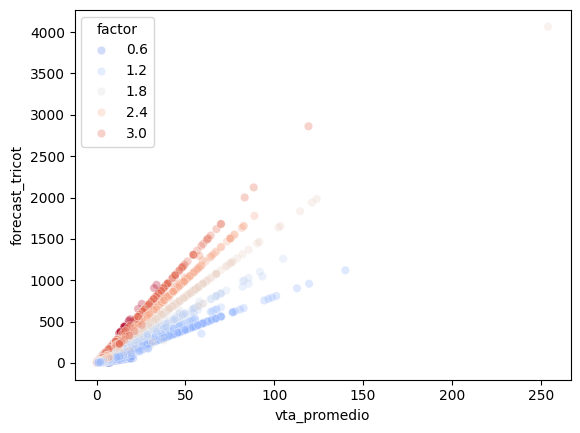

In [46]:
sns.scatterplot(x=tricot_df['vta_promedio'], y=tricot_df['forecast_tricot'], hue = tricot_df['factor'], palette='coolwarm', alpha=0.3)
plt.show()

In [47]:
data_repo_x_dda[['vta_promedio','mean_sales_next_4_weeks']].describe(percentiles=[.1, .25, .5, .75, .90]).round(2)

,vta_promedio,mean_sales_next_4_weeks
count,354456.00,354456.00
mean,1.53,0.94
std,3.23,1.43
min,0.25,0.00
10%,0.39,0.00
25%,0.58,0.25
50%,1.00,0.50
75%,1.47,1.25
90%,2.33,2.25
max,254.07,39.75


In [48]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from itertools import combinations

variables = ['vta_promedio', 'factor', 'semana_vta']

# Transformaciones log
X_all = np.log(tricot_df[variables].astype(float).clip(lower=1e-6))
y_log = np.log(tricot_df['forecast_tricot'].astype(float).clip(lower=1e-6))

resultados_log = {}

# probar todas las combinaciones (1, 2 y todas las variables)
for k in range(1, len(variables)+1):
    for combo in combinations(variables, k):
        Xc = X_all[list(combo)]
        
        model = LinearRegression()
        model.fit(Xc, y_log)
        y_pred = model.predict(Xc)
        
        r2 = r2_score(y_log, y_pred)
        resultados_log[combo] = round(r2, 4)

# Mostrar resultados
for combo, r2 in resultados_log.items():
    print(f"{combo}: R² (log-log) = {r2:.1%}")

('vta_promedio',): R² (log-log) = 73.3%
('factor',): R² (log-log) = 8.3%
('semana_vta',): R² (log-log) = 5.0%
('vta_promedio', 'factor'): R² (log-log) = 87.5%
('vta_promedio', 'semana_vta'): R² (log-log) = 82.3%
('factor', 'semana_vta'): R² (log-log) = 15.0%
('vta_promedio', 'factor', 'semana_vta'): R² (log-log) = 99.7%


1. **La variable que más explica las ventas es `vta_promedio`**

   * Por sí sola ya explica **más de 70%** del forecast.
   * Esto quiere decir que el **promedio de ventas históricas** es el principal motor del forecast.

2. **El `factor` tiene algo de peso, pero mucho menor**

   * Si lo usamos solo, apenas explica **10%**.
   * Pero cuando lo combinamos con `vta_promedio`, la explicación sube a **88%**.
   * Esto significa que **el factor complementa al promedio de ventas y mejora bastante el pronóstico**.

3. **La `semana_vta` aporta muy poquito**

   * Por sí sola apenas explica **3%**.
   * Incluso en combinaciones, su efecto es marginal frente a `vta_promedio` y `factor`.

4. **El modelo con las tres variables juntas es casi perfecto**

   * Usando las tres variables al mismo tiempo, el forecast se explica en un **98%**.
   * Es decir, prácticamente **podemos reconstruir el forecast con solo esas tres variables**.

---

## ✅ Conclusión para negocio

* **Driver clave:** el forecast depende principalmente de las **ventas promedio**.
* **Ajuste importante:** el **factor** es el segundo ingrediente, que mejora mucho la precisión.
* **Variable menor:** la **semana de venta** tiene un efecto pequeño, sirve para ajustes finos pero no cambia la historia.
* **Modelo final:** combinando las tres variables, se obtiene una **explicación casi total del forecast**.


In [49]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_log = np.log(tricot_df[['vta_promedio','factor','semana_vta']].astype(float).clip(lower=1e-6))
y_log = np.log(tricot_df['forecast_tricot'].astype(float).clip(lower=1e-6))

model = LinearRegression()
model.fit(X_log, y_log)
y_pred = model.predict(X_log)

print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R²:", r2_score(y_log, y_pred))

Coeficientes: [0.98965637 0.99102708 0.98976182]
Intercepto: 0.03483367477940558
R²: 0.9965254805520066


# Sandbox

In [50]:
data_repo_x_dda.query('semana_vta == 4')[['id']]

,id
6655,1273068102
6686,1273068103
6717,1273068105
7159,1273074103
7176,1273074105
...,...
27948449,226680299103
27948450,226680299103
27948463,226680299105
27948477,226680299106


In [51]:
data_all.query('id == "1273074103"')[['date','week_number','weekly_sales','vta_promedio','factor', 'semana_vta', 'forecast_tricot','real_sales', 'can_final']]

KeyError: "['date'] not in index"